# **Business Understanding**

# **Tentang Dataset**

### Deskripsi Dataset
Dataset ini adalah dataset penderita pernyakit **Diabetes Mellitus Tipe 2** berdasarkan berbagai faktor medis dan riwayat hidup.Dataset ini terdiri dari **768** jumlah data dan **9** fitur kolom dengan rincian kolomnya sebagai berikut :



1. Pregnancies: Jumlah kehamilan.
2. Glucose: Konsentrasi glukosa dalam plasma.
3. BloodPressure: Tekanan darah diastolik (mm Hg).
4. SkinThickness: Ketebalan lipatan kulit trisep (dalam milimeter).
5. Insulin: Kadar insulin dalam serum (dalam satuan mikro unit per mililiter).
6. BMI: 	Indeks massa tubuh (berat dalam kg dibagi tinggi kuadrat dalam meter)
7. DiabetesPedigreeFunction:  Fungsi silsilah diabetes (ukuran kemungkinan diabetes berdasarkan riwayat keluarga).
8. Age: Usia (dalam tahun).
9. Outcome: Diagnosis diabetes (0 = tidak diabetes, 1 = menderita diabetes).

### Sumber Dataset
Dataset pernyakit **Diabetes Mellitus Tipe 2** ini saya dapatkan dari **kaggle** dengan link sebagai berikut :  
 https://www.kaggle.com/code/rudenkobogdan/diabetics-prediction-detailed-analysis/notebook



---
---
# **Import Library Yang Dibutuhkan**

In [ ]:
# @title 1. Import modules, building classes and read CSV

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/diabetes2.csv')

# Bokeh Visualizer Class
Membuat class visualisasi data bernama **BokehVisualizer** yang digunakan untuk membuat berbagai jenis grafik interaktif menggunakan Bokeh dari sebuah DataFrame pandas

In [ ]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, FactorRange
from bokeh.transform import factor_cmap, cumsum
from bokeh.palettes import Category20, Spectral6
output_notebook()

class BokehVisualizer:
    def __init__(self, dataframe):
        self.df = dataframe
        output_notebook()

    def histogram(self, column, title='Histogram', colors=None, hue=None):
        data = self.df
        if hue:
            categories = data[hue].unique()
            if not colors:
                available_colors = Category20[20] if len(categories) > 10 else Category20[10]
                colors = available_colors[:len(categories)]
            color_dict = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}
            p = figure(title=title, background_fill_color="lightgray")
            for cat in categories:
                subset = data[data[hue] == cat]
                hist, edges = np.histogram(subset[column], bins=50)
                p.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:],
                       fill_color=color_dict[cat], line_color='black', fill_alpha=0.7, legend_label=str(cat))
            p.legend.location = "top_right"
        else:
            hist, edges = np.histogram(data[column], bins=50)
            p = figure(title=title, background_fill_color="lightgray")
            p.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:],
                   fill_color='blue', line_color='black', fill_alpha=0.7)
        p.xaxis.axis_label = column
        p.yaxis.axis_label = 'Count'
        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        show(p)

    def scatter(self, x_column, y_column, title='Scatter Plot', colors=None, hue=None):
        data = self.df
        source = ColumnDataSource(data)
        p = figure(title=title, background_fill_color="lightgray")
        if hue:
            categories = data[hue].unique()
            if not colors:
                colors = Category20[len(categories)] if len(categories) <= 20 else Spectral6 * (len(categories) // 6 + 1)
            mapper = factor_cmap(field_name=hue, palette=colors, factors=categories)
            p.scatter(x_column, y_column, source=source, color=mapper, legend_field=hue,
                      size=5, line_color='black', alpha=0.7)
            p.legend.location = "top_left"
        else:
            p.scatter(x_column, y_column, source=source, color='blue',
                      size=5, line_color='black', alpha=0.7)
        p.xaxis.axis_label = x_column
        p.yaxis.axis_label = y_column
        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        show(p)

    def box_plot(self, column, title='Box Plot', colors=None, hue=None):
        data = self.df
        if hue:
            categories = data[hue].unique().astype(str)
            if not colors:
                colors = Category20[len(categories)] if len(categories) <= 20 else Spectral6 * (len(categories) // 6 + 1)
            color_dict = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}
            p = figure(x_range=categories, title=title, background_fill_color="lightgray")

            for i, cat in enumerate(categories):
                subset = data[data[hue].astype(str) == cat]
                q1 = subset[column].quantile(0.25)
                q2 = subset[column].quantile(0.5)
                q3 = subset[column].quantile(0.75)
                iqr = q3 - q1
                upper = min(q3 + 1.5 * iqr, subset[column].max())
                lower = max(q1 - 1.5 * iqr, subset[column].min())

                p.segment([cat], [upper], [cat], [q3], line_color="black")
                p.segment([cat], [lower], [cat], [q1], line_color="black")
                p.vbar([cat], 0.7, q2, q3, fill_color=color_dict[cat], fill_alpha=0.5, line_color="black")
                p.vbar([cat], 0.7, q1, q2, fill_color=color_dict[cat], fill_alpha=0.5, line_color="black")

                jittered_x = [cat] * len(subset[column])
                p.circle(jittered_x, subset[column], size=5, color=color_dict[cat], alpha=0.6)
        else:
            q1 = data[column].quantile(0.25)
            q2 = data[column].quantile(0.5)
            q3 = data[column].quantile(0.75)
            iqr = q3 - q1
            upper = min(q3 + 1.5 * iqr, data[column].max())
            lower = max(q1 - 1.5 * iqr, data[column].min())
            p = figure(title=title, background_fill_color="lightgray")

            p.segment([1], [upper], [1], [q3], line_color="black")
            p.segment([1], [lower], [1], [q1], line_color="black")
            p.vbar([1], 0.7, q2, q3, fill_color='green', fill_alpha=0.5, line_color="black")
            p.vbar([1], 0.7, q1, q2, fill_color='green', fill_alpha=0.5, line_color="black")

            jittered_x = [1] * len(data[column])
            p.circle(jittered_x, data[column], size=5, color='green', alpha=0.6)

        p.yaxis.axis_label = column
        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        show(p)

    def line_plot(self, x_column, y_column, title='Line Plot', colors=None, hue=None):
        data = self.df
        p = figure(title=title, background_fill_color="lightgray", x_axis_type='auto')
        if hue:
            categories = data[hue].unique()
            if not colors:
                colors = Category20[len(categories)] if len(categories) <= 20 else Spectral6 * (len(categories) // 6 + 1)
            color_dict = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}
            for cat in categories:
                subset = data[data[hue] == cat]
                p.line(subset[x_column], subset[y_column], line_width=2,
                       color=color_dict[cat], legend_label=str(cat))
            p.legend.location = "top_left"
        else:
            p.line(data[x_column], data[y_column], line_width=2, color='blue')
        p.xaxis.axis_label = x_column
        p.yaxis.axis_label = y_column
        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        show(p)

    def bar_chart(self, x_column, y_column, title='Bar Chart', colors=None, hue=None):
        data = self.df
        if hue:
            categories = data[hue].unique().astype(str)
            x_factors = data[x_column].astype(str).unique()
            factors = [(x, cat) for x in x_factors for cat in categories]
            if not colors:
                colors = Category20[len(categories)] if len(categories) <= 20 else Spectral6 * (len(categories) // 6 + 1)
            source = ColumnDataSource(data=dict(
                x=[(str(x), str(cat)) for x, cat in zip(data[x_column], data[hue])],
                counts=data[y_column],
            ))
            p = figure(x_range=FactorRange(*factors), title=title, background_fill_color="lightgray")
            p.vbar(x='x', top='counts', width=0.9, source=source,
                   fill_color=factor_cmap('x', palette=colors, factors=categories, start=1, end=2))
            p.xaxis.axis_label = x_column
            p.yaxis.axis_label = y_column
            p.xaxis.major_label_orientation = 1
            p.legend.title = hue
        else:
            x = data[x_column].astype(str)
            counts = data[y_column]
            p = figure(x_range=x.unique(), title=title, background_fill_color="lightgray")
            p.vbar(x=x, top=counts, width=0.9, color='blue')
            p.xaxis.axis_label = x_column
            p.yaxis.axis_label = y_column
            p.xaxis.major_label_orientation = 1
        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        show(p)

    def pie_chart(self, column, title='Pie Chart'):
        data = self.df
        value_counts = data[column].value_counts()
        total = value_counts.sum()
        percentages = (value_counts / total) * 100

        filtered_value_counts = value_counts[percentages > 1]
        other_sum = value_counts[percentages <= 1].sum()
        if other_sum > 0:
            filtered_value_counts['Other'] = other_sum

        data = pd.DataFrame({
            'categories': filtered_value_counts.index.astype(str),
            'counts': filtered_value_counts.values
        })
        data['angle'] = data['counts'] / data['counts'].sum() * 2 * np.pi

        num_categories = len(data)
        if num_categories <= 20:
            if num_categories <= 2:
                palette = ['#1f77b4', '#ff7f0e'][:num_categories]
            elif num_categories <= 3:
                palette = Category20[3][:num_categories]
            elif num_categories <= 6:
                palette = Category20[6][:num_categories]
            elif num_categories <= 10:
                palette = Category20[10][:num_categories]
            else:
                palette = Category20[20][:num_categories]
        else:
            palette = viridis(num_categories)

        data['color'] = palette

        p = figure(title=title, background_fill_color="lightgray", tools="hover",
                   tooltips="@categories: @counts", x_range=(-0.5, 1.0))
        p.wedge(x=0, y=1, radius=0.4,
                start_angle=cumsum('angle', include_zero=True),
                end_angle=cumsum('angle'),
                line_color="white", fill_color='color', legend_field='categories', source=data)

        p.title.align = 'center'
        p.title.text_font_size = '20pt'
        p.title.text_color = 'darkblue'
        p.axis.axis_label = None
        p.axis.visible = False
        p.grid.grid_line_color = None
        show(p)

bv = BokehVisualizer(df)

---
---
# **Data Understanding**


# 2. Exploratory Data Analysis

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
target = 'Outcome'

# 3. Data Analysis

In [ ]:
missing_nan_count = df.isnull().sum()

missing_nan_count

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
bv.pie_chart(target, title='Pie Chart for Outcome value')

In [ ]:
# @title Pregnancies
df.Pregnancies.describe()

,Pregnancies
count,768.000000
mean,3.845052
std,3.369578
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,17.000000


In [ ]:
correlation = df.Pregnancies.corr(df.Outcome)
print(f"Correlation between pregnancies and outcome: {correlation}")

Correlation between pregnancies and outcome: 0.22189815303398613


Koefisien korelasi yang dihitung (0,2219) menunjukkan adanya korelasi positif yang lemah antara jumlah kehamilan dan target outcome. Meskipun ini menunjukkan bahwa jumlah kehamilan yang lebih tinggi mungkin sedikit meningkatkan kemungkinan terjadinya outcome tersebut, hubungan ini tidaklah kuat. Hal ini mengindikasikan bahwa faktor lain kemungkinan memiliki pengaruh yang lebih signifikan terhadap variabel target.

In [ ]:
bv.pie_chart('Pregnancies', title='Pie chart for number of pregnancies')

Diagram lingkaran ini menggambarkan distribusi jumlah kehamilan, di mana segmen terbesar berasal dari individu dengan 1 kali kehamilan, diikuti oleh mereka yang tidak pernah hamil (0). Keduanya mendominasi diagram, yang menunjukkan bahwa sebagian besar individu memiliki 0 atau 1 kehamilan. Kategori lainnya, seperti 2, 3, dan 4 kehamilan, memiliki porsi yang sedang, sementara jumlah kehamilan yang lebih tinggi (5 ke atas) menunjukkan proporsi yang semakin kecil. Hal ini menunjukkan adanya tren yang jelas bahwa jumlah kehamilan yang lebih sedikit jauh lebih umum pada populasi yang diteliti.

In [ ]:
bv.histogram('Pregnancies', hue=target, title='Distribution of Pregnancies')

Histogram ini menggambarkan distribusi jumlah kehamilan yang dikelompokkan berdasarkan hasil (0 atau 1). Mayoritas individu memiliki jumlah kehamilan yang sedikit, dengan jumlah terbanyak terlihat pada 0 dan 1 kehamilan. Seiring meningkatnya jumlah kehamilan, jumlah individu menurun secara signifikan, yang menunjukkan bahwa kehamilan dalam jumlah besar lebih jarang terjadi. Perbedaan antara hasil (outcome) menunjukkan bahwa individu dengan jumlah kehamilan yang sedikit lebih dominan di kedua kelompok hasil, meskipun proporsinya sedikit bervariasi di seluruh rentang.

In [ ]:
bv.box_plot('Pregnancies', title='Box Plot for Pregnancies')

Box plot ini menunjukkan distribusi jumlah kehamilan dalam dataset. Median jumlah kehamilan berada di sekitar angka 1, dengan rentang interkuartil (IQR) mencakup dari sekitar 0 hingga 3 kehamilan. Terdapat beberapa outlier di atas whisker bagian atas, yang mengindikasikan adanya sebagian kecil individu dengan jumlah kehamilan yang jauh lebih tinggi. Sebagian besar data berada di dalam IQR, menandakan bahwa mayoritas individu memiliki jumlah kehamilan yang relatif sedikit.

### Analisis distribusi jumlah kehamilan:
---

* Gambaran Distribusi: Sebagian besar individu dalam dataset memiliki 0 atau 1 kehamilan, yang menunjukkan bahwa jumlah kehamilan yang rendah jauh lebih umum. Jumlah kehamilan yang tinggi jarang terjadi dan tampak sebagai outlier dalam dataset.

* Korelasi dengan Hasil (Outcome): Terdapat korelasi positif yang lemah (0,22) antara jumlah kehamilan dengan outcome (hasil target), yang mengindikasikan bahwa semakin banyak jumlah kehamilan mungkin sedikit meningkatkan kemungkinan terjadinya outcome tersebut, namun faktor lain kemungkinan memainkan peran yang lebih penting.

* Segmentasi Berdasarkan Outcome: Ketika data dipisahkan berdasarkan outcome (0 atau 1), tren penurunan jumlah individu seiring dengan meningkatnya jumlah kehamilan tetap konsisten. Hal ini menunjukkan bahwa kedua kelompok outcome didominasi oleh individu dengan jumlah kehamilan yang sedikit, dengan hanya sedikit perbedaan proporsi antar outcome.


 ## **Glucose**

In [ ]:
df.Glucose.describe()

,Glucose
count,768.000000
mean,120.894531
std,31.972618
min,0.000000
25%,99.000000
50%,117.000000
75%,140.250000
max,199.000000


In [ ]:
correlation = df.Glucose.corr(df.Outcome)
print(f"Correlation between glucose and outcome: {correlation}")

Correlation between glucose and outcome: 0.46658139830687295


Koefisien korelasi antara kadar glukosa dan outcome (0,4666) menunjukkan adanya korelasi positif sedang. Ini mengindikasikan bahwa kadar glukosa yang lebih tinggi cenderung berhubungan dengan kemungkinan outcome yang lebih tinggi. Berbeda dengan jumlah kehamilan, glukosa tampaknya memiliki hubungan yang lebih kuat dengan variabel target, sehingga menjadi prediktor yang lebih signifikan dalam dataset.

In [ ]:
bv.histogram('Glucose', hue=target, title='Distribution of Glucose')

Histogram ini menunjukkan distribusi kadar glukosa yang dipisahkan berdasarkan outcome (0 dan 1). Pada individu dengan outcome 1, kadar glukosa cenderung lebih tinggi, dengan pergeseran yang terlihat ke sisi kanan grafik. Sebaliknya, individu dengan outcome 0 lebih terkonsentrasi pada kadar glukosa yang lebih rendah, dengan puncak di kisaran normal (~100 mg/dL). Pola ini sejalan dengan korelasi positif sedang yang telah diamati sebelumnya, yang mengindikasikan bahwa kadar glukosa yang tinggi berhubungan dengan kemungkinan outcome yang lebih besar. Selain itu, terdapat beberapa nilai anomali (misalnya, kadar glukosa nol) yang mungkin memerlukan penyelidikan lebih lanjut.

In [ ]:
bv.box_plot('Glucose', title='Box Plot for Glucose')

Box plot ini menyoroti distribusi kadar glukosa. Median kadar glukosa berada di tengah rentang interkuartil (IQR), yang mencakup sekitar 85 hingga 125. Data juga menunjukkan sejumlah besar outlier, terutama pada bagian ekstrem bawah dan atas. Kehadiran outlier dengan kadar glukosa nol tidak masuk akal secara biologis, yang mengindikasikan kemungkinan kesalahan entri data atau nilai yang hilang yang memerlukan imputasi. Secara keseluruhan, distribusi ini menunjukkan sedikit kemencengan (skewness) ke arah kadar glukosa yang lebih tinggi, yang sejalan dengan korelasinya terhadap outcome.

### Analisis distribusi kadar glukosa:
---
* Distribusi: Sebagian besar kadar glukosa berada dalam kisaran normal, yaitu sekitar 85-125 mg/dL, dengan distribusi yang terlihat menceng ke kanan. Individu dengan kadar glukosa yang lebih tinggi cenderung memiliki outcome 1, sebagaimana ditunjukkan dalam histogram.

* Korelasi: Terdapat korelasi positif sedang (0,4666) antara kadar glukosa dan outcome, yang menunjukkan bahwa kadar glukosa yang lebih tinggi berhubungan dengan peningkatan kemungkinan kondisi target. Hal ini menjadikan glukosa sebagai prediktor yang relatif kuat dibandingkan variabel lain yang dianalisis.

* Outlier: Box plot menunjukkan adanya beberapa outlier, terutama pada nilai ekstrem rendah, termasuk kadar glukosa nol, yang tidak masuk akal secara biologis. Nilai-nilai ini kemungkinan merupakan data yang hilang atau kesalahan entri, dan mungkin perlu dilakukan imputasi atau penghapusan.

* Pengamatan Utama: Kadar glukosa merupakan faktor penting dalam menentukan outcome, dengan pemisahan yang jelas antara individu dengan outcome 0 (terkonsentrasi pada kadar glukosa yang lebih rendah) dan outcome 1 (bergeser ke kadar glukosa yang lebih tinggi). Hal ini semakin menegaskan pentingnya variabel glukosa dalam dataset.

## **BloodPressure**

In [ ]:
df.BloodPressure.describe()

,BloodPressure
count,768.000000
mean,69.105469
std,19.355807
min,0.000000
25%,62.000000
50%,72.000000
75%,80.000000
max,122.000000


In [ ]:
correlation = df.BloodPressure.corr(df.Outcome)
print(f"Correlation between blood pressure and outcome: {correlation}")

Correlation between blood pressure and outcome: 0.0650683595503327


Koefisien korelasi antara tekanan darah dan outcome adalah 0,0651, yang menunjukkan korelasi positif yang sangat lemah. Hal ini mengindikasikan bahwa tingkat tekanan darah memiliki sedikit atau bahkan tidak ada hubungan linier dengan outcome dalam dataset. Oleh karena itu, tekanan darah kemungkinan bukan merupakan prediktor yang signifikan terhadap variabel target dibandingkan dengan fitur lain, seperti kadar glukosa. Penelitian lebih lanjut mungkin diperlukan untuk mengeksplorasi hubungan non-linier atau interaksi dengan variabel lain.

In [ ]:
bv.histogram('BloodPressure', hue=target, title='Distribution of Blood Pressure')

Histogram ini menggambarkan distribusi tekanan darah yang dipisahkan berdasarkan outcome (0 dan 1). Nilai tekanan darah terkonsentrasi di kisaran normal 60–80 mmHg, dengan puncak yang terlihat di sekitar 70 mmHg untuk kedua kelompok outcome. Tidak terdapat perbedaan yang signifikan antara kedua kelompok tersebut, yang menunjukkan bahwa tekanan darah tidak menjadi pembeda yang kuat antara outcome 0 dan 1. Kehadiran nilai nol kemungkinan merupakan indikasi data yang hilang atau entri yang salah, karena tekanan darah secara realistis tidak mungkin bernilai nol. Anomali ini mungkin perlu ditangani selama proses praproses data. Secara keseluruhan, tekanan darah menunjukkan variasi yang minimal antara kedua kelompok, sesuai dengan korelasi lemah yang diamati sebelumnya.

In [ ]:
bv.box_plot('BloodPressure', title='Box Plot for Blood Pressure')

Box plot tekanan darah menunjukkan bahwa sebagian besar nilai berada dalam rentang interkuartil (IQR) sekitar 60 hingga 80 mmHg, dengan median mendekati 70 mmHg. Distribusinya cukup simetris, namun terdapat beberapa outlier di bagian bawah maupun atas. Secara khusus, keberadaan nilai nol, yang tidak masuk akal secara biologis, mengindikasikan adanya kemungkinan kesalahan atau data yang hilang yang perlu ditangani selama proses praproses. Kekompakan IQR secara keseluruhan dan sebaran yang minimal menunjukkan bahwa tekanan darah tidak banyak bervariasi antar individu, yang sesuai dengan korelasi lemah yang diamati terhadap variabel outcome.

### Analisis distribusi tekanan darah:
---
* Distribusi: Nilai tekanan darah terkonsentrasi dalam kisaran normal 60–80 mmHg, dengan nilai yang paling umum berada di sekitar 70 mmHg. Kedua kelompok outcome (0 dan 1) menunjukkan distribusi yang serupa, dengan sedikit perbedaan di antara keduanya.

* Korelasi: Koefisien korelasi (0,0651) menunjukkan hubungan positif yang sangat lemah antara tekanan darah dan outcome. Hal ini mengindikasikan bahwa tekanan darah bukanlah prediktor yang kuat terhadap variabel target.

* Outlier: Box plot menyoroti adanya beberapa outlier, terutama pada nilai rendah, termasuk nilai nol. Nilai-nilai ini tidak masuk akal secara biologis dan kemungkinan besar merupakan data yang hilang atau entri yang salah, sehingga perlu ditangani dalam proses pembersihan dan praproses data.

* Pengamatan Utama: Tekanan darah menunjukkan variasi yang minimal di seluruh dataset, dan hubungannya dengan outcome sangat kecil jika dibandingkan dengan prediktor yang lebih kuat seperti kadar glukosa. Hal ini menjadikan tekanan darah sebagai fitur yang kurang signifikan dalam dataset.

## **SkinThickness**

In [ ]:
df.SkinThickness.describe()

,SkinThickness
count,768.000000
mean,20.536458
std,15.952218
min,0.000000
25%,0.000000
50%,23.000000
75%,32.000000
max,99.000000


In [ ]:
correlation = df.SkinThickness.corr(df.Outcome)
print(f"Correlation between SkinThickness and Outcome: {correlation}")

Correlation between SkinThickness and Outcome: 0.0747522319183194


Koefisien korelasi antara ketebalan kulit dan outcome adalah 0,0748, yang menunjukkan korelasi positif yang sangat lemah. Ini mengindikasikan bahwa ketebalan kulit memiliki hubungan linier yang sangat kecil dengan outcome target. Seperti halnya tekanan darah, ketebalan kulit kemungkinan bukan merupakan prediktor yang kuat terhadap outcome secara mandiri, meskipun perannya bersama variabel lain masih dapat dieksplorasi.

In [ ]:
bv.histogram('SkinThickness', hue=target, title='Distribution of Skin Thickness')

Histogram ini menampilkan distribusi ketebalan kulit yang dipisahkan berdasarkan outcome (0 dan 1). Sebagian besar titik data memiliki nilai 0, yang tidak realistis dan kemungkinan menunjukkan data yang hilang yang perlu ditangani. Untuk nilai selain nol, distribusinya tampak mendekati normal, dengan sebagian besar pengukuran terkonsentrasi antara 20 hingga 40 mm. Kedua kelompok outcome menunjukkan distribusi yang serupa, dengan sedikit tumpang tindih, yang memperkuat korelasi sangat lemah yang diamati sebelumnya. Nilai nol yang tidak realistis ini sangat memengaruhi distribusi dan harus ditangani untuk memastikan analisis yang bermakna.

In [ ]:
bv.box_plot('SkinThickness', title='Box Plot for Skin Thickness')

Box plot untuk ketebalan kulit menunjukkan bahwa sebagian besar nilai terkonsentrasi dalam rentang interkuartil (IQR) sekitar 20 hingga 40 mm, dengan median sekitar 30 mm. Plot ini juga menunjukkan banyak outlier, terutama pada bagian bawah, termasuk banyak nilai nol, yang tidak masuk akal secara biologis dan kemungkinan besar merupakan data yang hilang atau salah. Beberapa outlier di bagian atas (di atas 60 mm) menunjukkan kasus langka dengan ketebalan kulit yang sangat tinggi. Anomali ini, terutama nilai nol, sangat memengaruhi distribusi dan harus ditangani selama proses praproses data untuk memastikan akurasi analisis.

### Analisis Distribusi Ketebalan Kulit:
---
* Distribusi: Sebagian besar nilai ketebalan kulit berada di antara 20 hingga 40 mm, dengan median sekitar 30 mm. Distribusinya tampak mendekati normal untuk nilai selain nol, namun proporsi data dengan nilai 0 cukup signifikan, yang tidak realistis dan kemungkinan merupakan data yang hilang atau kesalahan pencatatan.

* Korelasi: Koefisien korelasi dengan outcome (0,0748) sangat lemah, yang menunjukkan bahwa ketebalan kulit secara mandiri bukan merupakan prediktor yang kuat terhadap variabel target.

* Outlier: Box plot menyoroti banyak outlier, terutama nilai nol di bagian bawah dan beberapa nilai ekstrem di atas 60 mm pada bagian atas. Nilai nol ini sangat memengaruhi analisis dan harus ditangani, misalnya melalui imputasi atau penghapusan data.

## **Insulin**

In [ ]:
df.Insulin.describe()

,Insulin
count,768.000000
mean,79.799479
std,115.244002
min,0.000000
25%,0.000000
50%,30.500000
75%,127.250000
max,846.000000


In [ ]:
correlation = df.Insulin.corr(df.Outcome)
print(f"Correlation between Insulin and Outcome: {correlation}")

Correlation between Insulin and Outcome: 0.13054795488404794


Koefisien korelasi antara kadar insulin dan outcome adalah 0,1305, yang menunjukkan korelasi positif yang lemah. Hal ini mengindikasikan bahwa kadar insulin memiliki hubungan linier yang kecil, namun tidak kuat, dengan outcome target. Meskipun insulin mungkin bukan prediktor yang sangat berpengaruh secara mandiri, ia masih dapat memberikan informasi yang berguna jika dipertimbangkan bersama variabel lainnya. Penyelidikan lebih lanjut terhadap distribusi dan anomali (seperti nilai nol atau data yang hilang) diperlukan untuk analisis yang lebih mendalam.

In [ ]:
bv.histogram('Insulin', hue=target, title='Distribution of Insulin')

Histogram ini menggambarkan distribusi kadar insulin, dengan proporsi nilai yang signifikan terkonsentrasi pada angka 0. Nilai nol ini tidak realistis dan kemungkinan besar merupakan data yang hilang atau hasil imputasi, yang sangat memengaruhi distribusi. Untuk nilai selain nol, distribusinya menceng ke kanan, dengan sebagian besar nilai berada di bawah 200.

Kedua kelompok outcome (0 dan 1) menunjukkan distribusi yang serupa, tanpa pemisahan yang jelas antara keduanya. Hal ini sesuai dengan korelasi positif lemah (0,1305) yang diamati sebelumnya, yang menunjukkan bahwa kadar insulin hanya memiliki sedikit hubungan dengan outcome. Penanganan nilai nol, baik melalui imputasi maupun penghapusan, sangat penting untuk analisis yang bermakna terhadap peran insulin.

In [ ]:
bv.box_plot('Insulin', title='Box Plot for Insulin')

Box plot untuk kadar insulin menunjukkan distribusi yang sangat menceng ke kanan, dengan sebagian besar nilai terkonsentrasi di bawah 200. Rentang interkuartil (IQR) berada di kisaran sekitar 0 hingga 100, dengan median mendekati angka 80. Terdapat banyak outlier, terutama di bagian atas, dengan beberapa nilai melebihi 600.

Selain itu, keberadaan nilai nol yang signifikan—yang tidak masuk akal secara biologis—menunjukkan adanya data yang hilang atau kesalahan pencatatan yang memerlukan penanganan dalam tahap praproses data. Nilai nol ini mendistorsi analisis dan perlu ditangani, karena dapat menyembunyikan pola-pola penting dalam data.

### Analisis Distribusi Insulin:
---

1. Distribusi: Distribusi kadar insulin sangat menceng ke kanan, dengan sebagian besar nilai berada di bawah 200. Sebagian besar data mengandung nilai nol, yang tidak masuk akal secara biologis dan kemungkinan besar merupakan data yang hilang atau hasil imputasi.

2. Korelasi: Koefisien korelasi antara insulin dan outcome adalah 0,1305, yang menunjukkan hubungan positif yang lemah. Ini berarti insulin secara mandiri bukanlah prediktor yang kuat terhadap outcome.

3. Outlier: Box plot menunjukkan banyak outlier, terutama di bagian atas, dengan beberapa nilai melebihi 600. Nilai-nilai ini mencerminkan kasus langka dengan kadar insulin yang sangat tinggi.

4. Pengamatan Utama:

* Nilai nol mendistorsi distribusi dan harus ditangani melalui proses imputasi atau penghapusan selama praproses data.

* Kadar insulin hanya menunjukkan hubungan yang lemah dengan outcome, tetapi tetap dapat memberikan kontribusi dalam model prediksi jika digabungkan dengan variabel lain.

* Menangani nilai yang hilang dan menganalisis interaksi dengan fitur lain dapat meningkatkan wawasan yang diperoleh dari variabel ini.











 ## **BMI**

In [ ]:
df.BMI.describe()

,BMI
count,768.000000
mean,31.992578
std,7.884160
min,0.000000
25%,27.300000
50%,32.000000
75%,36.600000
max,67.100000


In [ ]:
correlation = df.BMI.corr(df.Outcome)
print(f"Correlation between BMI and Outcome: {correlation}")

Correlation between BMI and Outcome: 0.29269466264444494


Korelasi antara BMI dan outcome adalah 0,293, yang menunjukkan hubungan positif sedang. Ini mengindikasikan bahwa nilai BMI yang lebih tinggi secara moderat berhubungan dengan kemungkinan outcome yang lebih besar. Meskipun korelasinya tidak kuat, BMI tampaknya memiliki relevansi prediktif dalam dataset ini.

In [ ]:
bv.histogram('BMI', hue=target, title='Distribution of BMI')

Distribusi BMI menunjukkan puncak di sekitar angka 30, dengan sebagian besar nilai berada di antara 20 hingga 40. Individu dengan outcome 1 cenderung memiliki nilai BMI yang sedikit lebih tinggi dibandingkan dengan individu dengan outcome 0. Meskipun terdapat tumpang tindih antara kedua kelompok, distribusi ini menunjukkan tren bahwa BMI yang lebih tinggi lebih sering dikaitkan dengan outcome 1. Selain itu, terdapat beberapa outlier ekstrem yang melebihi angka 50, serta sejumlah kecil nilai nol yang kemungkinan merupakan data yang hilang.

In [ ]:
bv.box_plot('BMI', title='BMI')

Box plot untuk BMI menunjukkan bahwa rentang interkuartil (IQR) terkonsentrasi antara sekitar 25 hingga 35, dengan median di kisaran 30. Terdapat sejumlah outlier di atas angka 40, yang menunjukkan kasus dengan nilai BMI sangat tinggi. Selain itu, terdapat nilai nol di bagian bawah, yang tidak realistis dan kemungkinan besar merupakan data yang hilang atau keliru. Data ini sedikit menceng ke arah nilai BMI yang lebih tinggi karena adanya outlier tersebut.

### Analisis Distribusi BMI:
---
1. Distribusi: Nilai BMI menunjukkan distribusi yang hampir normal, dengan sebagian besar data terkonsentrasi antara 20 hingga 40. Median berada di sekitar angka 30, dan terdapat beberapa nilai ekstrem yang melebihi 50. Selain itu, terdapat nilai nol yang kemungkinan menunjukkan data yang hilang dan perlu ditangani dalam tahap praproses.

2. Wawasan dari Box Plot: Rentang interkuartil (IQR) berada di antara sekitar 25 hingga 35, dengan outlier di atas 40 yang menunjukkan kasus dengan nilai BMI yang sangat tinggi. Keberadaan nilai nol di bagian bawah menegaskan perlunya pembersihan data.

3. Korelasi: Koefisien korelasi sebesar 0,293 menunjukkan hubungan positif sedang antara BMI dan outcome, yang berarti bahwa nilai BMI yang lebih tinggi secara moderat berkaitan dengan peningkatan kemungkinan outcome yang positif.

4. Pengamatan Utama:

- BMI merupakan prediktor yang cukup signifikan dalam dataset ini, dengan nilai yang lebih tinggi cenderung berkaitan dengan outcome positif.

* Nilai nol yang hilang atau salah harus ditangani melalui imputasi atau penghapusan.

- Kekuatan prediktif BMI kemungkinan akan meningkat jika dikombinasikan dengan variabel lain dalam pemodelan.

## **DiabetesPedigreeFunction**

In [ ]:
df.DiabetesPedigreeFunction.describe()

,DiabetesPedigreeFunction
count,768.000000
mean,0.471876
std,0.331329
min,0.078000
25%,0.243750
50%,0.372500
75%,0.626250
max,2.420000


In [ ]:
correlation = df.DiabetesPedigreeFunction.corr(df.Outcome)
print(f"Correlation between DiabetesPedigreeFunction and Outcome: {correlation}")

Correlation between DiabetesPedigreeFunction and Outcome: 0.1738440656529596


Korelasi antara Diabetes Pedigree Function (DPF) dan outcome adalah 0,1738, yang menunjukkan hubungan positif yang lemah. Hal ini mengindikasikan bahwa individu dengan nilai DPF yang lebih tinggi sedikit lebih mungkin memiliki outcome yang positif, namun asosiasinya tidak kuat. Meskipun demikian, DPF masih dapat memberikan kontribusi terhadap kekuatan prediktif model jika digabungkan dengan variabel lainnya.

In [ ]:
bv.histogram('DiabetesPedigreeFunction', hue=target, title='Distribution of DiabetesPedigreeFunction')

Distribusi Diabetes Pedigree Function (DPF) sangat menceng ke kanan, dengan sebagian besar nilai terkonsentrasi antara 0 hingga 0,5. Nilai DPF yang lebih tinggi, di atas 1,0, jarang ditemukan. Kedua kelompok outcome (0 dan 1) menunjukkan distribusi yang serupa, namun individu dengan outcome 1 tampak sedikit lebih banyak pada nilai DPF yang lebih tinggi. Hal ini sejalan dengan korelasi positif yang lemah yang telah diamati sebelumnya, yang mengindikasikan bahwa meskipun DPF mungkin berperan, ia bukanlah prediktor yang kuat secara mandiri terhadap outcome.

In [ ]:
bv.box_plot('DiabetesPedigreeFunction', title='Box Plot for DiabetesPedigreeFunction')

Box plot untuk Diabetes Pedigree Function (DPF) menunjukkan bahwa sebagian besar nilai berada dalam rentang interkuartil (IQR) sekitar 0,25 hingga 0,6, dengan median di kisaran 0,35. Distribusinya sangat menceng ke kanan, dengan sejumlah outlier yang mencolok melebihi angka 1,0, dan beberapa bahkan mencapai lebih dari 2,5. Outlier tersebut merepresentasikan individu dengan nilai DPF yang sangat tinggi. Secara keseluruhan, sebaran data menunjukkan bahwa meskipun sebagian besar nilai DPF tergolong kecil, nilai-nilai tinggi yang jarang ini mungkin memiliki pengaruh terhadap outcome.

### Analisis Distribusi Diabetes Pedigree Function (DPF):
---
1. Distribusi: Distribusi DPF sangat menceng ke kanan, dengan sebagian besar nilai terkonsentrasi antara 0 hingga 0,5. Nilai yang lebih tinggi dari 1,0 jarang ditemukan, dan nilai yang melebihi 2,5 sangat jarang terjadi.

2. Wawasan dari Box Plot: Rentang interkuartil (IQR) mencakup sekitar 0,25 hingga 0,6, dengan median di kisaran 0,35. Terdapat banyak outlier di atas 1,0, yang menunjukkan individu dengan nilai DPF yang sangat tinggi dan tidak umum.

3. Korelasi: Korelasi antara DPF dan outcome tergolong lemah (0,1738), yang mengindikasikan bahwa nilai DPF yang lebih tinggi hanya sedikit berhubungan dengan outcome yang positif.

4. Pengamatan Utama:

* DPF memberikan nilai prediktif tertentu, namun bukan indikator kuat secara mandiri terhadap outcome.

* Outlier dengan nilai DPF yang sangat tinggi mungkin merepresentasikan kasus unik dan bisa memberikan wawasan tambahan jika dianalisis lebih lanjut.

* Variabel ini dapat berinteraksi dengan fitur lain untuk meningkatkan performa prediksi dalam pemodelan.











## **Age**

In [ ]:
df.Age.describe()

,Age
count,768.000000
mean,33.240885
std,11.760232
min,21.000000
25%,24.000000
50%,29.000000
75%,41.000000
max,81.000000


In [ ]:
correlation = df.Age.corr(df.Outcome)
print(f"Correlation between Age and Outcome: {correlation}")

Correlation between Age and Outcome: 0.23835598302719754


Korelasi antara usia dan outcome adalah 0,2384, yang menunjukkan hubungan positif lemah hingga sedang. Hal ini mengindikasikan bahwa individu yang lebih tua sedikit lebih mungkin memiliki outcome yang positif, namun usia saja bukan merupakan prediktor yang kuat. Meskipun demikian, usia tetap dapat memberikan informasi yang berguna, terutama bila dikombinasikan dengan variabel lainnya.

In [ ]:
bv.histogram('Age', hue=target, title='Distribution of Age')

Distribusi usia sangat menceng ke kanan, dengan mayoritas individu berada pada rentang usia muda, khususnya antara 20–30 tahun. Seiring bertambahnya usia, frekuensi data menurun secara signifikan. Kedua kelompok outcome (0 dan 1) menunjukkan tren yang serupa, namun individu dengan outcome 1 sedikit lebih banyak pada usia yang lebih tua. Hal ini sesuai dengan korelasi positif lemah hingga sedang yang diamati sebelumnya, menunjukkan bahwa usia berkontribusi secara moderat dalam memprediksi outcome, dengan individu yang lebih tua sedikit lebih mungkin memiliki outcome positif.

In [ ]:
bv.box_plot('Age', title='Box Plot for Age')

Box plot untuk usia menunjukkan bahwa sebagian besar individu berada dalam rentang interkuartil (IQR) sekitar 25 hingga 40 tahun, dengan median di kisaran 30 tahun. Distribusi ini menceng ke kanan, dengan beberapa outlier di atas 65 tahun. Ini mencerminkan tren yang terlihat pada histogram, di mana usia muda mendominasi dataset. Outlier tersebut merepresentasikan individu yang lebih tua dan mungkin memiliki sedikit pengaruh terhadap hubungan antara usia dan outcome.

###**Analisis Distribusi Usia:**
---

1. **Distribusi:** Distribusi usia sangat menceng ke kanan, dengan sebagian besar individu terkonsentrasi pada rentang usia 20 hingga 30 tahun. Frekuensi menurun secara signifikan seiring bertambahnya usia, dan sangat sedikit individu yang berusia di atas 60 tahun.

2. **Wawasan dari Box Plot:** Rentang interkuartil (IQR) berada pada kisaran sekitar 25 hingga 40 tahun, dengan median sekitar 30 tahun. Beberapa outlier di atas usia 65 merepresentasikan individu tertua dalam dataset.

3. **Korelasi:** Koefisien korelasi antara usia dan outcome adalah 0,2384, yang menunjukkan hubungan positif lemah hingga sedang. Individu yang lebih tua sedikit lebih mungkin memiliki outcome yang positif.

4. **Pengamatan Utama:**

  * Usia memberikan nilai prediktif tertentu, dengan individu yang lebih tua menunjukkan kemungkinan sedikit lebih tinggi untuk memiliki outcome positif.
  * Meskipun hubungan ini tidak kuat, usia dapat memberikan kekuatan prediksi yang lebih baik bila dikombinasikan dengan variabel lain.
  * Distribusi usia condong ke individu yang lebih muda, dan keberadaan outlier usia yang lebih tua dapat sedikit memengaruhi hasil analisis.


## **Kesimpulan**

### **Kesimpulan dari Hasil Analisis:**

1. **Kehamilan (Pregnancies):**

   * Sebagian besar individu memiliki 0–1 kali kehamilan; jumlah yang lebih tinggi jarang terjadi.
   * Korelasi positif lemah dengan outcome (**0,22**).

2. **Glukosa (Glucose):**

   * Korelasi positif sedang (**0,47**) dengan outcome.
   * Kadar glukosa yang lebih tinggi berkaitan dengan kemungkinan outcome positif.

3. **Tekanan Darah (Blood Pressure):**

   * Korelasi positif lemah (**0,065**); pengaruhnya terhadap outcome sangat kecil.
   * Banyak nilai nol yang kemungkinan besar merupakan data yang hilang.

4. **Ketebalan Kulit (Skin Thickness):**

   * Korelasi positif lemah (**0,075**) dengan outcome.
   * Banyak nilai nol dan beberapa outlier di sisi atas.

5. **Insulin:**

   * Korelasi positif lemah (**0,13**) dengan outcome.
   * Distribusi sangat menceng ke kanan dengan banyak nilai nol (kemungkinan data hilang).

6. **BMI (Indeks Massa Tubuh):**

   * Korelasi positif sedang (**0,29**) dengan outcome.
   * BMI yang lebih tinggi cenderung berkaitan dengan outcome positif.

7. **Fungsi Keturunan Diabetes (Diabetes Pedigree Function/DPF):**

   * Korelasi positif lemah (**0,17**) dengan outcome.
   * Sebagian besar nilai kecil, dengan outlier bernilai tinggi yang jarang.

8. **Usia (Age):**

   * Korelasi positif lemah hingga sedang (**0,24**) dengan outcome.
   * Individu muda mendominasi dataset, namun individu yang lebih tua sedikit lebih mungkin memiliki outcome positif.


# **Visualisasi Korelasi Antar Fitur (Heatmap Segitiga)**

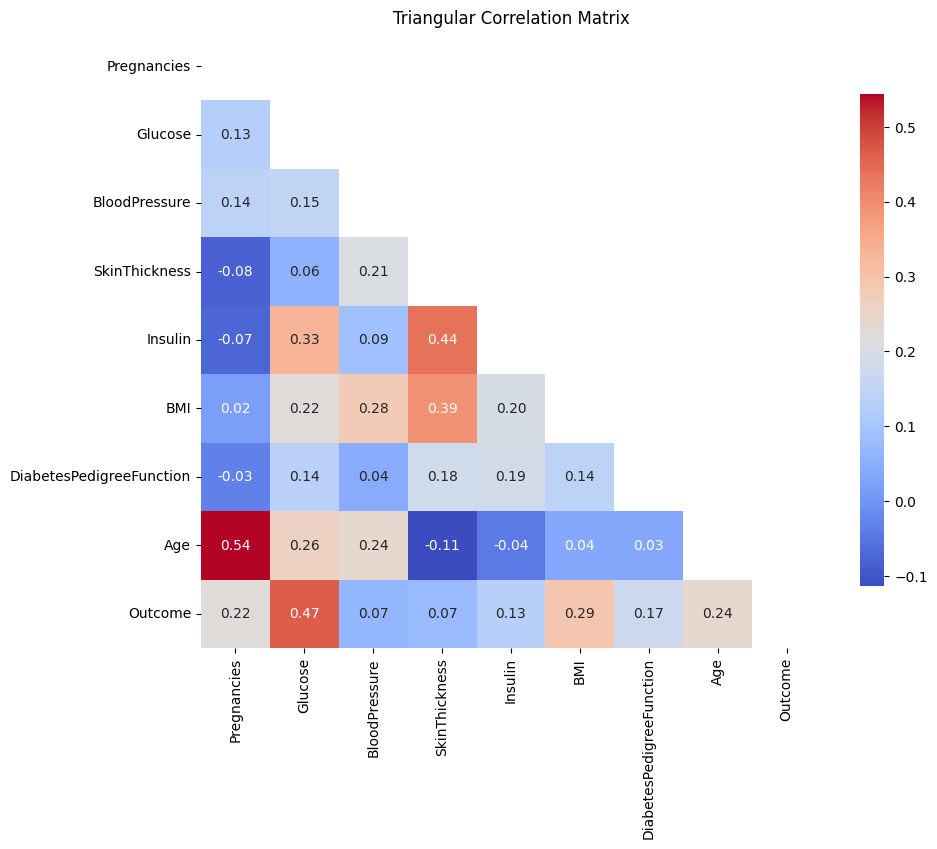

In [ ]:
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap with the mask
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={"shrink": 0.8})
plt.title('Triangular Correlation Matrix')
plt.show()

# **Visualisasi Hubungan Antar Variabel Berdasarkan Outcome**

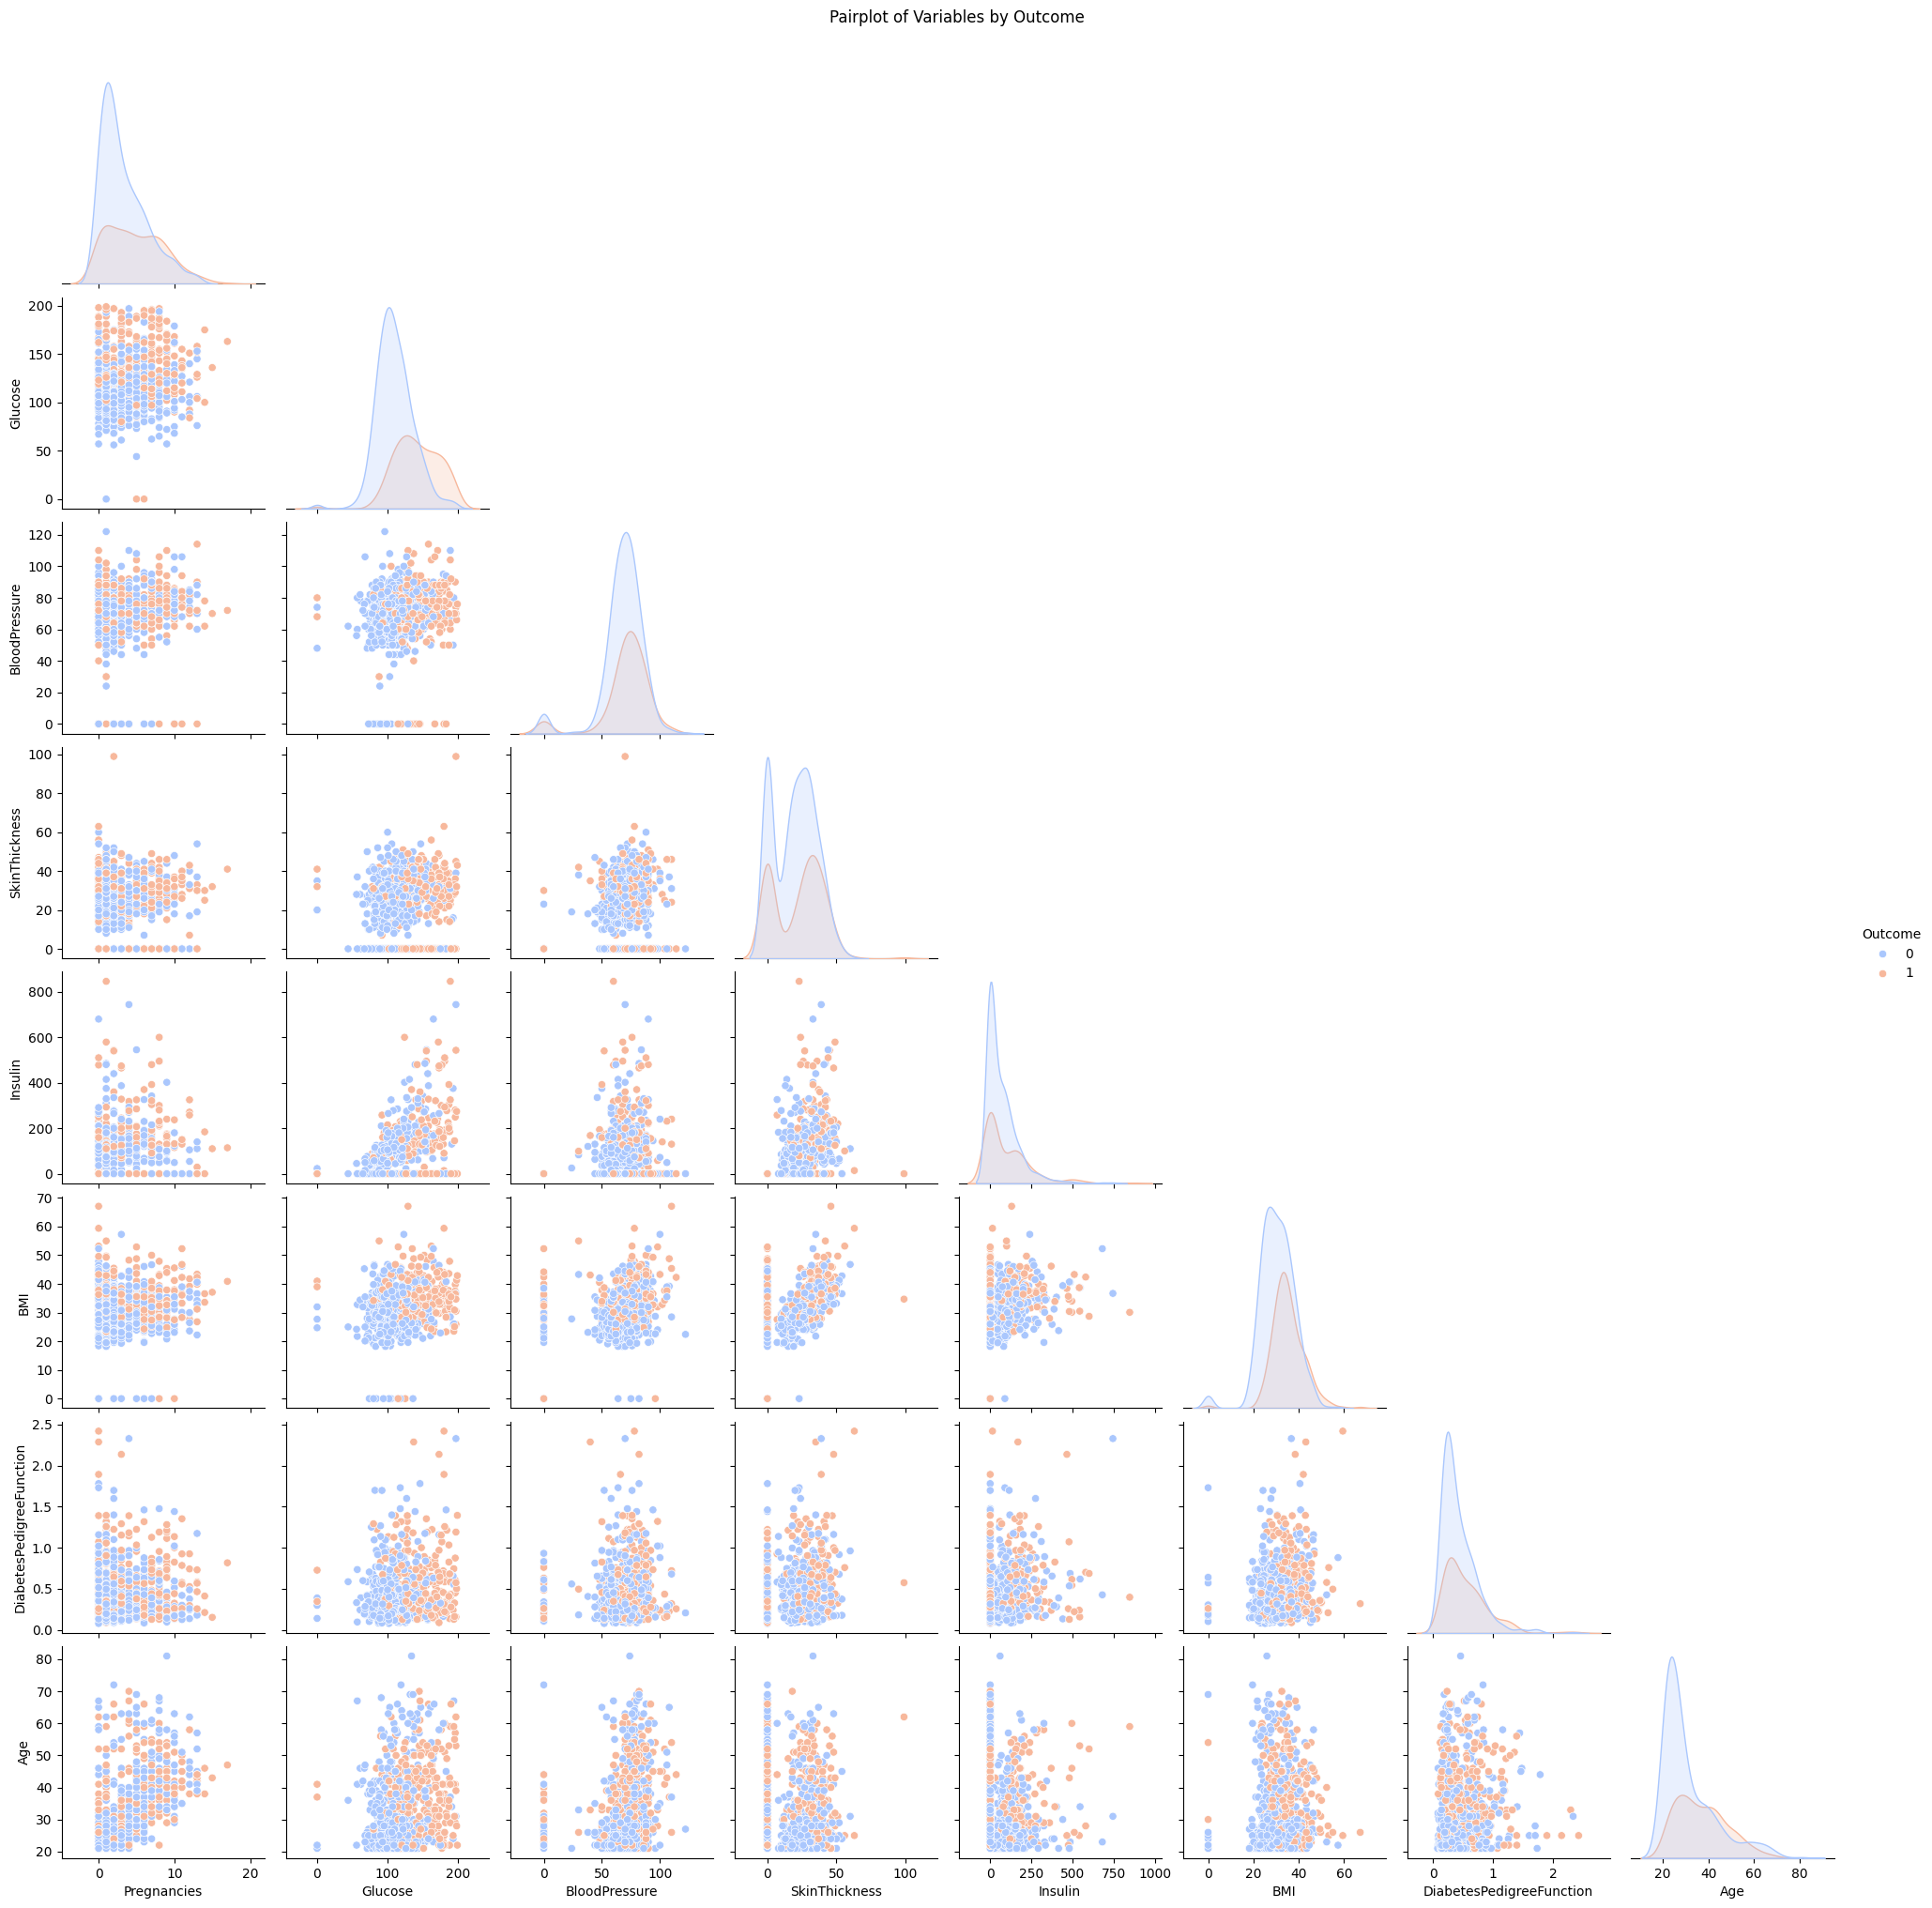

In [ ]:
sns.pairplot(df, hue='Outcome', diag_kind='kde', palette='coolwarm', corner=True)
plt.suptitle('Pairplot of Variables by Outcome', y=1.02)
plt.show()

---
---
# **Data Preparation**

## Data Cleaning for the dataset based on the analysis above

In [ ]:
# 1. Ubah semua kolom menjadi numerik (untuk menghindari error jika ada data non-angka)
df_cleaned = df.apply(pd.to_numeric, errors='coerce')

# 2. Tangani nilai tidak valid atau hilang dengan mengganti angka 0 menjadi NaN pada kolom yang relevan
kolom_nilai_tidak_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_cleaned[kolom_nilai_tidak_valid] = df_cleaned[kolom_nilai_tidak_valid].replace(0, np.nan)

# 3. Hapus baris yang memiliki nilai hilang pada kolom penting seperti Glucose dan BMI
df_cleaned = df_cleaned.dropna(subset=['Glucose', 'BMI'])

# 4. Isi nilai hilang lainnya (jika masih ada) dengan nilai median dari masing-masing kolom
df_cleaned = df_cleaned.fillna(df_cleaned.median())

# 5. Pastikan data yang telah dibersihkan siap untuk dianalisis lebih lanjut
df_cleaned.info()

# Tampilkan beberapa baris pertama dari data yang sudah dibersihkan
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               752 non-null    int64  
 1   Glucose                   752 non-null    float64
 2   BloodPressure             752 non-null    float64
 3   SkinThickness             752 non-null    float64
 4   Insulin                   752 non-null    float64
 5   BMI                       752 non-null    float64
 6   DiabetesPedigreeFunction  752 non-null    float64
 7   Age                       752 non-null    int64  
 8   Outcome                   752 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 58.8 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.5,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
#fitur (X) dan target (y)
# Fitur adalah semua kolom kecuali 'Outcome', sedangkan 'Outcome' adalah label/target yang ingin diprediksi
X = df_cleaned.drop(columns=['Outcome'])
y = df_cleaned['Outcome']

# Parameter stratify memastikan distribusi kelas pada data latih dan uji tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan jumlah data pada masing-masing bagian (train dan test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((601, 8), (151, 8), (601,), (151,))

# **4. Model Building**

In [ ]:
# Block 1: Logistic Regression
def logistic_regression(X_train, y_train, X_test, y_test):
    model = LogisticRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print("Logistic Regression:")
    print("Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

<a id='c5'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b> 5. Validation </b></div>

## Logistic regression

In [ ]:
logistic_regression(X_train, y_train, X_test, y_test)

Logistic Regression:
Accuracy: 0.7748344370860927
              precision    recall  f1-score   support

           0       0.76      0.95      0.85        98
           1       0.83      0.45      0.59        53

    accuracy                           0.77       151
   macro avg       0.79      0.70      0.72       151
weighted avg       0.79      0.77      0.75       151



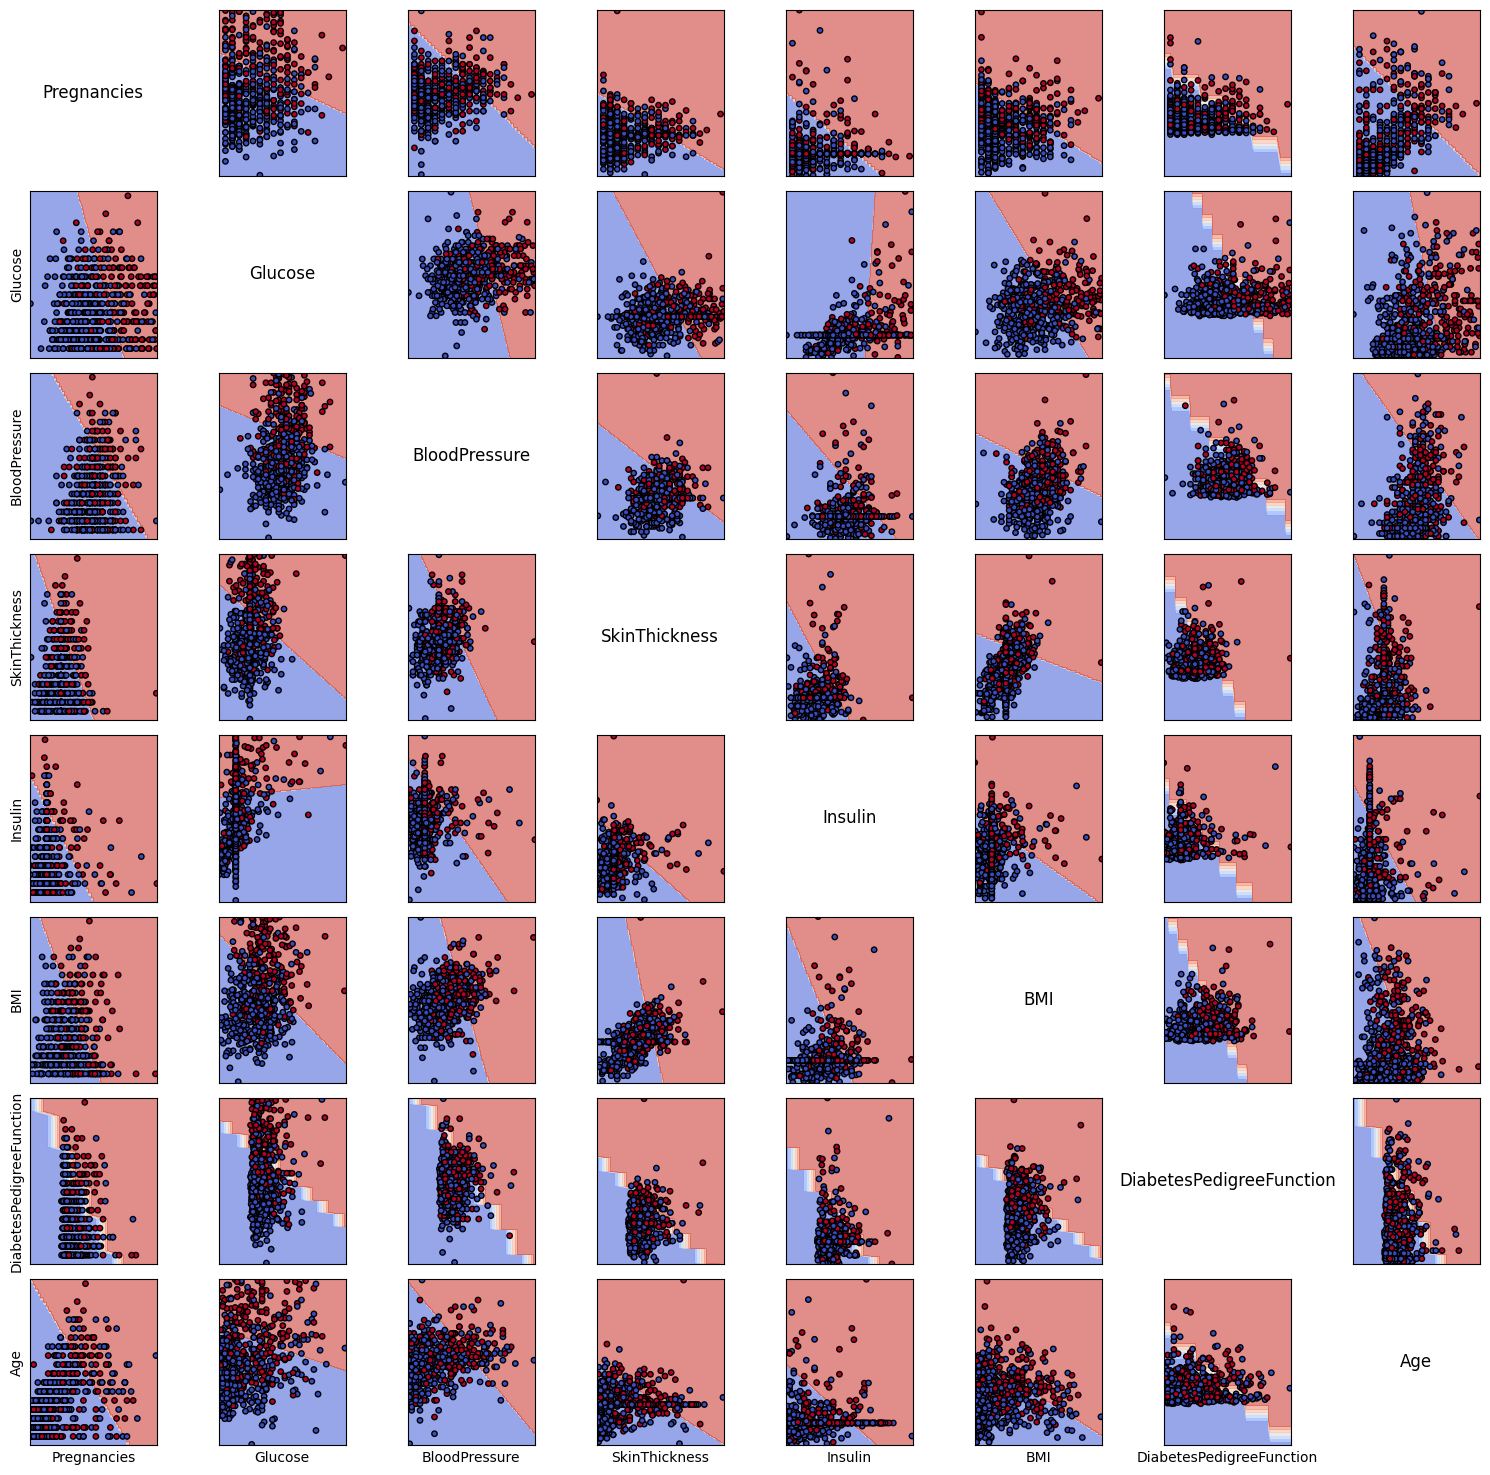

In [ ]:
# Generate decision boundaries for all unique pairs of features
def plot_all_feature_pairs(model_class, X, y, title=""):
    feature_names = X.columns
    n_features = len(feature_names)
    fig, axes = plt.subplots(n_features, n_features, figsize=(15, 15))

    for i, feature_x in enumerate(feature_names):
        for j, feature_y in enumerate(feature_names):
            ax = axes[i, j]
            if i == j:  # Diagonal elements (same feature)
                ax.text(0.5, 0.5, feature_x, fontsize=12, ha='center', va='center')
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_frame_on(False)
                continue

            # Use only two features at a time
            X_pair = X[[feature_x, feature_y]]
            model = model_class()
            model.fit(X_pair, y)

            # Create meshgrid for decision boundaries
            x_min, x_max = X_pair.iloc[:, 0].min() - 1, X_pair.iloc[:, 0].max() + 1
            y_min, y_max = X_pair.iloc[:, 1].min() - 1, X_pair.iloc[:, 1].max() + 1
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                                 np.arange(y_min, y_max, 0.5))
            grid = np.c_[xx.ravel(), yy.ravel()]
            Z = model.predict(grid)
            Z = Z.reshape(xx.shape)

            # Plot decision boundary
            ax.contourf(xx, yy, Z, alpha=0.6, cmap='coolwarm')
            ax.scatter(X_pair.iloc[:, 0], X_pair.iloc[:, 1], c=y, edgecolor='k', cmap='coolwarm', s=15)
            ax.set_xticks([])
            ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(feature_x, fontsize=10)
            if i == n_features - 1:
                ax.set_xlabel(feature_y, fontsize=10)

    fig.suptitle(title, fontsize=16, y=0.92)
    plt.tight_layout()
    plt.show()


# Plot decision boundaries for logistic regression across all feature pairs
plot_all_feature_pairs(LogisticRegression, X_train, y_train)


# **Evaluasi**

<a id='c6'></a>
# <div style="text-align:center; border-radius:15px 15px; padding:15px; color:#333333; margin:0; ; padding:15px; font-size:100%; font:'Verdana'; background-color:#F5F5F5;border: 1px; overflow:hidden"><b> 6. Results </b></div>

## 🔍 **Analisis Efektivitas Model: Logistic Regression**

### **1. Logistic Regression**

**Akurasi:** **77,48%**

### **Kekuatan:**

* **Precision tinggi untuk kelas 1 (0,83)** → menunjukkan bahwa model jarang salah memprediksi positif (false positive rendah).
* **Performa sangat baik untuk kelas 0**, dengan **recall sebesar 0,95** dan **f1-score sebesar 0,85** → artinya sebagian besar negatif terdeteksi dengan benar.

### **Kelemahan:**

* **Recall untuk kelas 1 cukup rendah (0,45)** → banyak kasus positif yang tidak terdeteksi (false negative tinggi).
* **Kurang optimal jika kelas 1 jumlahnya sedikit** atau **fitur-fitur dari kelas 0 dan 1 terlalu mirip**.

### **Kesimpulan:**

* Logistic Regression menunjukkan **performa seimbang secara keseluruhan**, terutama untuk dataset yang tidak terlalu kompleks dan memiliki batas keputusan yang linier.
* Cocok untuk penggunaan awal dan **mudah diinterpretasikan**, serta memberikan **hasil yang solid tanpa overfitting**.

